In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_vagas = pd.read_parquet('../data/processed/vagas_cursos_tratados.parquet')
df_matriculas = pd.read_parquet('../data/processed/microdados_matriculas_tratados.parquet')

In [2]:
df_vagas.head(10)

,codigo_ciclo_matricula,vagas_regulares_l1,vagas_regulares_l2,vagas_regulares_l5,vagas_regulares_l6,vagas_regulares_l9,vagas_regulares_ac
0,802715,0,0,0,0,0,40
1,805360,1,7,1,7,1,20
2,805366,1,6,1,5,0,14
3,1209276,2,6,2,10,0,20
4,1209283,2,6,2,10,0,20
5,1209717,1,7,1,7,1,20
6,1251999,0,0,0,0,0,40
7,1254683,2,4,2,4,0,15
8,1255338,1,6,1,5,0,14
9,1255340,1,6,1,5,0,14


**Tratamento de valores ausentes**

In [11]:
# Detectar valores ausentes
df_vagas.isna().sum()

codigo_ciclo_matricula    0
vagas_regulares_l1        0
vagas_regulares_l2        0
vagas_regulares_l5        0
vagas_regulares_l6        0
vagas_regulares_l9        0
vagas_regulares_ac        0
dtype: int64

In [4]:
# Identificar as colunas de vagas dinamicamente, excluindo a chave do curso
colunas_vagas = df_vagas.columns.difference(['codigo_ciclo_matricula']).tolist()

# Substituir os valores nulos estruturais (<NA>) por 0 em bloco
df_vagas[colunas_vagas] = df_vagas[colunas_vagas].fillna(0)

In [12]:
df_vagas.describe()

,vagas_regulares_l1,vagas_regulares_l2,vagas_regulares_l5,vagas_regulares_l6,vagas_regulares_l9,vagas_regulares_ac
count,599.0,599.0,599.0,599.0,599.0,599.0
mean,1.542571,6.657763,1.524207,6.42404,0.292154,18.777963
std,1.106884,4.055807,1.256022,4.114639,0.731372,14.122699
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,1.0,6.0,1.0,5.0,0.0,15.0
50%,2.0,7.0,1.0,7.0,0.0,19.0
75%,2.0,7.0,2.0,7.0,0.0,20.0
max,14.0,56.0,17.0,56.0,8.0,204.0


**Dicionário de Termos e Critérios da Lei de Cotas (Lei nº 12.711/2012)**

Para interpretar a distribuição estatística das vagas ofertadas, os códigos das colunas devem ser associados aos critérios regulamentares de reserva de vagas no Ensino Superior Federal:

* **`vagas_regulares_ac` (Ampla Concorrência):** Vagas universais, abertas a qualquer candidato sem exigência de critérios socioeconômicos ou demográficos.
* **`vagas_regulares_l1` (Cota L1):** Vagas reservadas a estudantes que cursaram integralmente o Ensino Médio em **Escola Pública** e possuem renda familiar per capita de **baixa renda** (até 1 salário mínimo).
* **`vagas_regulares_l2` (Cota L2):** Vagas reservadas a estudantes de **Escola Pública**, de **Baixa Renda**, autodeclarados **Pretos, Pardos ou Indígenas (PPI)**.
* **`vagas_regulares_l5` (Cota L5):** Vagas reservadas a estudantes de **Escola Pública**, com **Renda Livre** (sem necessidade de comprovação de renda).
* **`vagas_regulares_l6` (Cota L6):** Vagas reservadas a estudantes de **Escola Pública**, de **Renda Livre**, autodeclarados **Pretos, Pardos ou Indígenas (PPI)**.
* **`vagas_regulares_l9` (Cota L9):** Vagas reservadas a estudantes de **Escola Pública**, de **Baixa Renda** e que sejam **Pessoas com Deficiência (PCD)**.

> **Regra de Proporcionalidade:** Os recortes raciais (PPI) e de deficiência (PCD) aplicados nas cotas pares (`L2`, `L6`) e nas cotas de inclusão especial (`L9`) seguem estritamente a proporção demográfica dessas populações no estado da Bahia, com base nos dados oficiais do censo do IBGE.


In [ ]:
# Contar a quantidade de ciclos unicos (turmas) por unidade de ensino
contagem_cursos = (
    df_matriculas
    .groupby('unidade_ensino')['codigo_ciclo_matricula']
    .nunique()
    .sort_values(ascending=False)
)

# Renomear as colunas para o formato legivel de relatorio
contagem_cursos.index.name = 'Unidade de Ensino (Campus)'
contagem_cursos.name = 'Quantidade de Turmas/Ciclos'

# Exibir a tabela descritiva
print("=== DISTRIBUIÇÃO DE CICLOS POR CAMPUS ===")
display(contagem_cursos)


=== DISTRIBUIÇÃO DE CURSOS POR CAMPUS ===


Unidade de Ensino (Campus)
Campus Salvador                  174
Campus Vitória da Conquista       75
Campus Porto Seguro               49
Campus Valença Tento              37
Campus Santo Antônio de Jesus     31
Campus Barreiras                  27
Campus Eunápolis                  27
Campus Camaçari                   25
Campus Irecê                      25
Campus Paulo Afonso               24
Campus Simões Filho               22
Campus Santo Amaro                21
Campus Lauro de Freitas           18
Campus Feira de Santana           13
Campus Jequié                      9
Campus Jacobina                    8
Campus Brumado                     6
Campus Ilhéus                      3
Campus Avançado Ubaitaba           2
Campus Juazeiro                    2
Campus Seabra                      1
Name: Quantidade de Cursos/Ciclos, dtype: int64

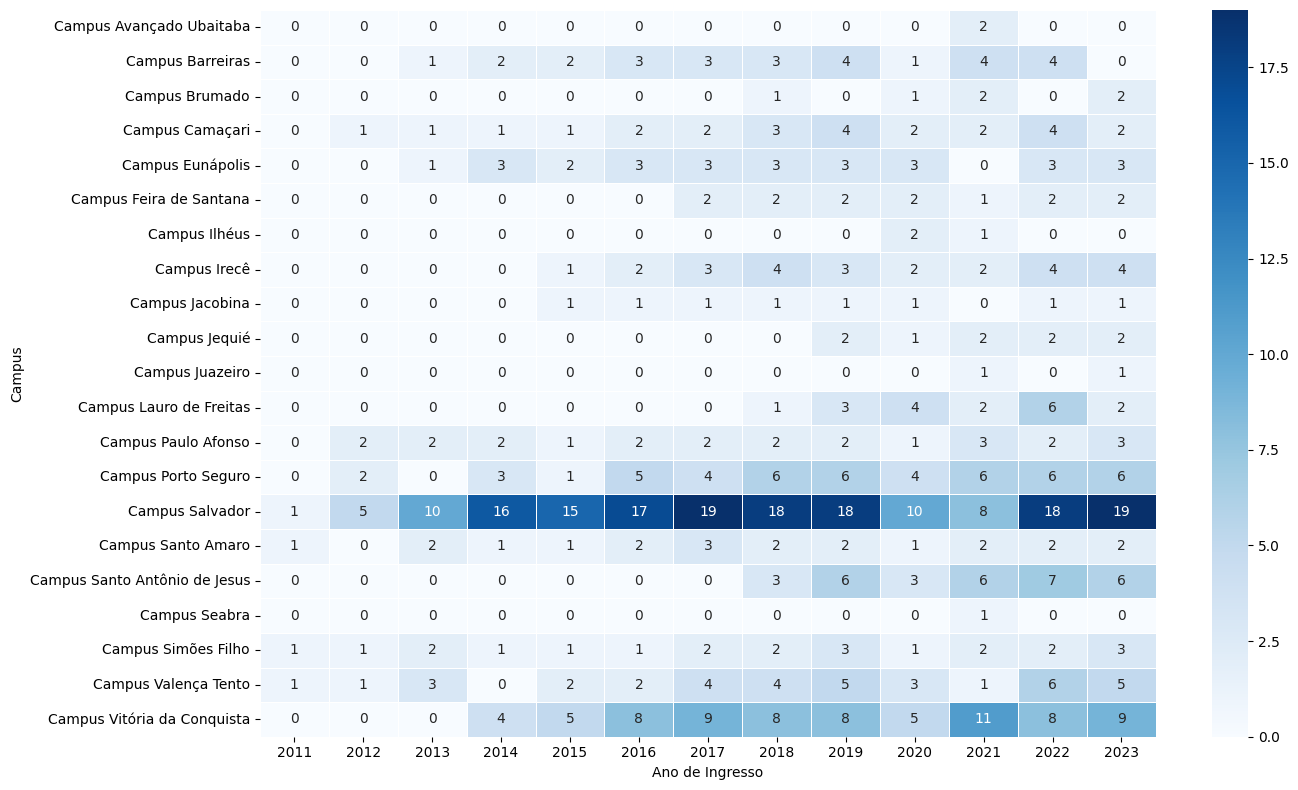

In [16]:
# Trazer ano de ingresso de cada ciclo único
df_ciclos = df_matriculas[['codigo_ciclo_matricula', 'unidade_ensino', 'data_inicio_ciclo']]\
    .drop_duplicates(subset=['codigo_ciclo_matricula'])
df_ciclos['ano_ingresso'] = pd.to_datetime(df_ciclos['data_inicio_ciclo'], errors='coerce').dt.year

# Pivot: campus × ano → contagem de ciclos abertos
pivot_ciclos = df_ciclos.pivot_table(
    index='unidade_ensino',
    columns='ano_ingresso',
    values='codigo_ciclo_matricula',
    aggfunc='count',
    fill_value=0
)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_ciclos, annot=True, fmt='d', cmap='Blues', linewidths=0.4)
#plt.title('Ciclos de Matrícula Abertos por Campus e Ano de Ingresso')
plt.xlabel('Ano de Ingresso')
plt.ylabel('Campus')
plt.tight_layout()
plt.show()